In [1]:
import json
import os
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from _plotting_style import CAT_COLORS, SEQ_COLORS


import sys
sys.path.append('..')

import warnings
warnings.filterwarnings("ignore")

from omegaconf import OmegaConf

from implicit_nuisance.data.base import prepare_data
from implicit_nuisance.methods import METHODS
from implicit_nuisance.utils.offline_model_eval import get_states_and_decodings

from implicit_nuisance.data.dot_motion import get_video_frames, save_videos_as_gifs_and_pdfs

# seed everything
from lightning.pytorch import seed_everything

In [2]:
def get_checkpoints_by_seed(model_name):
    """Return {seed: ckpt_dir} keeping the most recent run per unique seed."""
    folder = Path("../trained_models") / model_name
    seed_to_dir = {}  # seed -> (ctime, Path)
    for run_dir in sorted(folder.iterdir()):
        if not run_dir.is_dir():
            continue
        args_file = run_dir / "args.json"
        if not args_file.exists():
            continue
        with open(args_file) as f:
            args = json.load(f)
        seed = args.get("seed", None)
        if seed is None:
            continue
        ctime = run_dir.stat().st_ctime
        if seed not in seed_to_dir or ctime > seed_to_dir[seed][0]:
            seed_to_dir[seed] = (ctime, run_dir)
    return {seed: d for seed, (_, d) in seed_to_dir.items()}


def load_model_from_ckpt_dir(ckpt_dir, num_test_sequences=1000, data_seed=3):
    """Load a trained model and evaluate it on a fresh validation set."""
    ckpt_dir = Path(ckpt_dir)
    with open(ckpt_dir / "args.json") as f:
        method_args = json.load(f)
    cfg = OmegaConf.create(method_args)

    # build validation loader (fixed data seed so all models see the same data)
    cfg_data = OmegaConf.create(method_args)
    cfg_data.data.settings.num_train_sequences = 1000
    cfg_data.data.settings.num_test_sequences = num_test_sequences
    cfg_data.seed = data_seed
    cfg_data.data.settings.seed = data_seed
    cfg_data.data.settings.sample_seed = data_seed
    seed_everything(data_seed, workers=True)
    _, val_loader = prepare_data(cfg_data)

    # load checkpoint
    ckpt_paths = [ckpt_dir / fn for fn in os.listdir(ckpt_dir) if fn.endswith(".ckpt")]
    ckpt_path = ckpt_paths[0]
    cfg.optimizer.batch_size = 64
    model = METHODS[method_args["method"]].load_from_checkpoint(ckpt_path, strict=False, cfg=cfg)
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    data, labels, latents, decodings = get_states_and_decodings(device, model, val_loader)
    return data, labels, latents, decodings, model, cfg


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

def _flatten_last_dim(x):
    x = x.detach().cpu().numpy()
    return x.reshape(-1, x.shape[-1])

def linear_pos_r2(train_labels, train_latents, test_labels=None, test_latents=None, feature_key="inferences", test_size=0.25, random_state=0):
    X = _flatten_last_dim(train_latents[feature_key])
    y = _flatten_last_dim(train_labels["pos"])
    if X.shape[0] != y.shape[0]:
        raise ValueError(f"feature/target sample mismatch: {X.shape[0]} vs {y.shape[0]}")

    if test_labels is None or test_latents is None:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, shuffle=True
        )
    else:
        X_train, y_train = X, y
        X_test = _flatten_last_dim(test_latents[feature_key])
        y_test = _flatten_last_dim(test_labels["pos"])
        if X_test.shape[0] != y_test.shape[0]:
            raise ValueError(f"test feature/target sample mismatch: {X_test.shape[0]} vs {y_test.shape[0]}")

    reg = LinearRegression().fit(X_train, y_train)
    return r2_score(y_test, reg.predict(X_test))


In [4]:
# model_dict = {}      # model_name -> {seed: (data, labels, latents, decodings, model, cfg)}

# names = ["infoLDM_randstep_nuisance_logdet"]
# for name in names:
#     model_name = f"{name}"
#     ckpt_by_seed = get_checkpoints_by_seed(model_name)
#     print(f"Loading {model_name}: {len(ckpt_by_seed)} seed(s): {sorted(ckpt_by_seed)}")
#     model_dict[model_name] = {}
#     for seed, ckpt_dir in ckpt_by_seed.items():
#         model_dict[model_name][seed] = load_model_from_ckpt_dir(ckpt_dir)

In [5]:
model_dict = {}      # model_name -> {seed: (data, labels, latents, decodings, model, cfg)}

names = ["randstep_knn", "randstep_kde", "randstep_logdet"]
ns = [5,10,15,20]

for name in names:
    for n in ns:
        model_name = f"{name}_{n}"
        ckpt_by_seed = get_checkpoints_by_seed(model_name)
        print(f"Loading {model_name}: {len(ckpt_by_seed)} seed(s): {sorted(ckpt_by_seed)}")
        model_dict[model_name] = {}
        for seed, ckpt_dir in ckpt_by_seed.items():
            model_dict[model_name][seed] = load_model_from_ckpt_dir(ckpt_dir)


Seed set to 3


Loading randstep_knn_5: 5 seed(s): [1, 2, 3, 4, 5]


Seed set to 3
Seed set to 3
Seed set to 3
Seed set to 3
Seed set to 3


Loading randstep_knn_10: 5 seed(s): [1, 2, 3, 4, 5]


Seed set to 3
Seed set to 3
Seed set to 3
Seed set to 3
Seed set to 3


...

Seed set to 3
Seed set to 3
Seed set to 3
Seed set to 3
Seed set to 3


Loading randstep_logdet_15: 5 seed(s): [1, 2, 3, 4, 5]


Seed set to 3
Seed set to 3
Seed set to 3
Seed set to 3
Seed set to 3


Loading randstep_logdet_20: 5 seed(s): [1, 2, 3, 4, 5]


Seed set to 3
Seed set to 3
Seed set to 3
Seed set to 3


In [6]:
# plot settings
P_height = 0.7
P_width = 3
plot_folder = "plots/paper/"
Path(plot_folder).mkdir(parents=True, exist_ok=True)

In [7]:
batch_ind = 0

def extract_examples(mdict):
    """Return {model_name: {seed: (data_i, labels_i, latents_i, decodings_i)}}."""
    out = {}
    for model_name, seed_dict in mdict.items():
        out[model_name] = {}
        for seed, tpl in seed_dict.items():
            data, labels, latents, decodings, model, cfg = tpl
            out[model_name][seed] = (
                data[batch_ind][:],
                {k: labels[batch_ind][k][:] for k in labels[batch_ind]},
                {k: latents[batch_ind][k][:] for k in latents[batch_ind]},
                {k: decodings[batch_ind][k][:] for k in decodings[batch_ind]},
            )
    return out

model_examples      = extract_examples(model_dict)
# model_examples_long = extract_examples(model_dict_long)


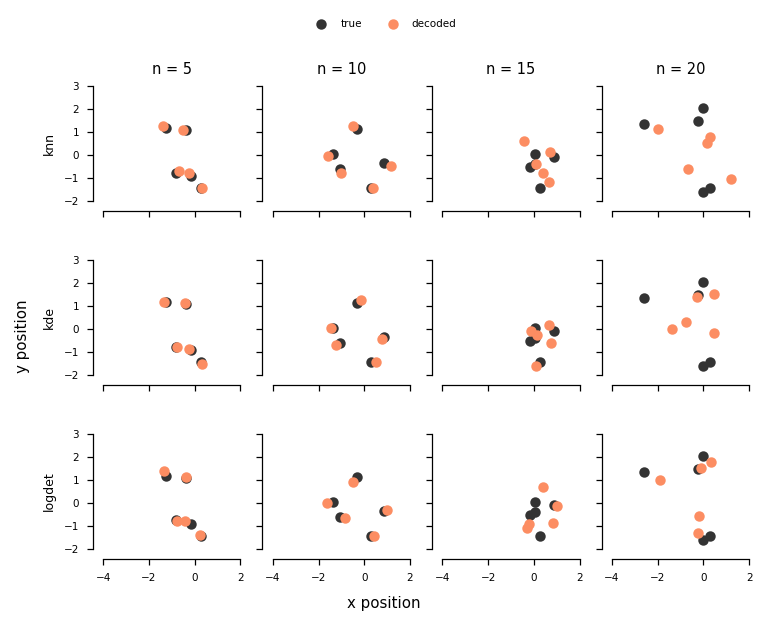

In [8]:
# Compare the true and decoded position trajectories for one held-out sequence.
video_ind = 0
fig, axs = plt.subplots(len(names), len(ns), figsize=(1.25 * len(ns), 1.25 * len(names)), sharex=True, sharey=True)

for row, name in enumerate(names):
    for col, n in enumerate(ns):
        ax = axs[row, col]
        seed_dict = model_examples[f"{name}_{n}"]
        seed = next(iter(seed_dict))
        _, labels_i, _, decodings_i = seed_dict[seed]
        true_pos = labels_i["signal"][video_ind].cpu().numpy()
        decoded_pos = decodings_i["signal"][video_ind].cpu().numpy()

        ax.scatter(true_pos[:, 0], true_pos[:, 1], color="0.2", label="true" if row == col == 0 else None)
        ax.scatter(decoded_pos[:, 0], decoded_pos[:, 1], color=CAT_COLORS[1], label="decoded" if row == col == 0 else None)
        # ax.scatter(true_pos[0, 0], true_pos[0, 1], zorder=3)
        # ax.scatter(decoded_pos[0, 0], decoded_pos[0, 1], zorder=3)
        ax.set_aspect("equal")
        if row == 0:
            ax.set_title(f"n = {n}")
        if col == 0:
            ax.set_ylabel(name.replace("randstep_", ""))

fig.supxlabel("x position")
fig.supylabel("y position")
fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.08))
plt.savefig(plot_folder + "randstep_true_vs_decoded_positions.pdf")
plt.show()


In [9]:
# r2_scores[name] = array of shape (len(ns), num_seeds)
r2_scores      = {name: [[] for _ in ns] for name in names}

for name in names:
    for ni, n in enumerate(ns):
        model_name      = f"{name}_{n}"
        model_name_long = f"{name}_{n}_long"

        for seed in model_examples[model_name]:
            _, labels_i, latents_i, _ = model_examples[model_name][seed]
            r2_scores[name][ni].append(linear_pos_r2(labels_i, latents_i))

        # for seed in model_examples_long[model_name_long]:
        #     _, labels_i, latents_i, _ = model_examples_long[model_name_long][seed]
        #     r2_scores_long[name][ni].append(linear_pos_r2(labels_i, latents_i))

        r2_mean  = np.mean(r2_scores[name][ni])
        # r2_mean_long = np.mean(r2_scores_long[name][ni])
        print(f"{model_name}  r2={r2_mean:.4f} ({len(r2_scores[name][ni])} seeds)  ")
            #   f"long r2={r2_mean_long:.4f} ({len(r2_scores_long[name][ni])} seeds)")


randstep_knn_5  r2=0.9849 (5 seeds)  
randstep_knn_10  r2=0.9489 (5 seeds)  
randstep_knn_15  r2=0.7571 (5 seeds)  
randstep_knn_20  r2=0.6410 (5 seeds)  
randstep_kde_5  r2=0.9156 (5 seeds)  
randstep_kde_10  r2=0.8145 (5 seeds)  
randstep_kde_15  r2=0.5993 (5 seeds)  
randstep_kde_20  r2=0.4750 (5 seeds)  
randstep_logdet_5  r2=0.9912 (5 seeds)  
randstep_logdet_10  r2=0.9506 (5 seeds)  
randstep_logdet_15  r2=0.7813 (5 seeds)  
randstep_logdet_20  r2=0.6806 (5 seeds)  


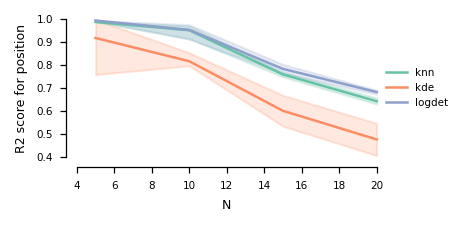

In [10]:
rng = np.random.default_rng(0)
n_bootstrap = 10_000
confidence_level = 0.95

plt.figure(figsize=(P_width, 2*P_height))
for name in names:
    s = name.replace("randstep_", "")
    mean = np.array([np.mean(r2_scores[name][ni]) for ni in range(len(ns))])
    ci = []
    for ni in range(len(ns)):
        scores = np.asarray(r2_scores[name][ni])
        bootstrap_means = rng.choice(scores, size=(n_bootstrap, len(scores)), replace=True).mean(axis=1)
        alpha = (1 - confidence_level) / 2
        ci.append(np.quantile(bootstrap_means, [alpha, 1 - alpha]))
    ci = np.asarray(ci).T
    (line,) = plt.plot(ns, mean, label=s)
    plt.fill_between(ns, ci[0], ci[1], alpha=0.2, color=line.get_color())
plt.xlabel("N")
plt.ylabel("R2 score for position")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


In [25]:
for name in names:
    values = []
    for ni in range(len(ns)):
        mean = np.mean(r2_scores[name][ni])
        std = np.std(r2_scores[name][ni])
        value = f"{mean:.2f} \\pm {std:.2f}"

        if mean > 0.9:
            value = f"\\mathbf{{{value}}}"

        values.append(f"${value}$")

    print(
        f"{name.replace('randstep_', '')} & "
        + " & ".join(values)
        + " "
        + "\\" * 2
    )

knn & $\mathbf{0.98 \pm 0.00}$ & $\mathbf{0.95 \pm 0.04}$ & $0.76 \pm 0.01$ & $0.64 \pm 0.02$ \\
kde & $\mathbf{0.92 \pm 0.16}$ & $0.81 \pm 0.04$ & $0.60 \pm 0.08$ & $0.48 \pm 0.08$ \\
logdet & $\mathbf{0.99 \pm 0.00}$ & $\mathbf{0.95 \pm 0.04}$ & $0.78 \pm 0.02$ & $0.68 \pm 0.01$ \\


## Uniform initial marginal

The uniform experiment changes only $S_0$: $S_0 \sim U([0,1]^{d_S})$. Successor conditionals remain fixed-covariance Gaussians, and their marginals are not expected to remain uniform. The cells below therefore diagnose the initial law and successor calibration separately.

In [12]:
# uniform_model_dict = {}
# uniform_names = ["randstep_uniform_kde", "randstep_uniform_knn", "randstep_uniform_logdet"]

# for name in uniform_names:
#     for n in ns:
#         model_name = f"{name}_{n}"
#         ckpt_by_seed = get_checkpoints_by_seed(model_name)
#         print(f"Loading {model_name}: {len(ckpt_by_seed)} seed(s): {sorted(ckpt_by_seed)}")
#         uniform_model_dict[model_name] = {}
#         for seed, ckpt_dir in ckpt_by_seed.items():
#             uniform_model_dict[model_name][seed] = load_model_from_ckpt_dir(ckpt_dir)


In [13]:
# from implicit_nuisance.utils.causal3dident_eval import evaluate_gaussian_conditional
# from implicit_nuisance.utils.random_step_nuisance_eval import evaluate_initial_distribution

# def _concat_sequence_batches(batches, key):
#     return torch.cat([batch[key].detach().cpu() for batch in batches], dim=0).numpy()

# def summarize_random_step_run(run):
#     _, labels, latents, _, _, cfg = run
#     signal = _concat_sequence_batches(labels, "signal")
#     transition_mean = _concat_sequence_batches(labels, "transition_mean")
#     transition_std = _concat_sequence_batches(labels, "transition_std")
#     inference = _concat_sequence_batches(latents, "inferences")
#     prediction = _concat_sequence_batches(latents, "predictions")
#     prediction_variance = _concat_sequence_batches(latents, "predictions_variances")

#     initial_distribution = OmegaConf.select(
#         cfg, "data.settings.initial_distribution", default="gaussian"
#     )
#     initial = evaluate_initial_distribution(signal[:, 0], initial_distribution)
#     source = evaluate_gaussian_conditional(
#         signal[:, 1:].reshape(-1, signal.shape[-1]),
#         transition_mean[:, 1:].reshape(-1, signal.shape[-1]),
#         transition_std[0, 1] ** 2,
#     )
#     model = evaluate_gaussian_conditional(
#         inference[:, 1:].reshape(-1, inference.shape[-1]),
#         prediction[:, :-1].reshape(-1, prediction.shape[-1]),
#         prediction_variance[0, 0],
#     )
#     return {"initial": initial, "source_transition": source, "model_transition": model}


In [14]:
# uniform_diagnostics = {}
# for model_name, seed_dict in uniform_model_dict.items():
#     uniform_diagnostics[model_name] = {}
#     for seed, run in seed_dict.items():
#         metrics = summarize_random_step_run(run)
#         uniform_diagnostics[model_name][seed] = metrics
#         initial = metrics["initial"]
#         source = metrics["source_transition"]
#         model = metrics["model_transition"]
#         print(
#             f"{model_name}, seed={seed}: "
#             f"initial KS(max)={max(initial['ks_statistic']):.3f}, "
#             f"in cube={initial.get('fraction_in_unit_cube', float('nan')):.3f}, "
#             f"source Mahalanobis={source['mean_squared_mahalanobis']:.3f}, "
#             f"model Mahalanobis={model['mean_squared_mahalanobis']:.3f}, "
#             f"model NLL/dim={model['mean_gaussian_nll_per_dimension']:.3f}"
#         )
# uniform_examples = extract_examples(uniform_model_dict)

In [15]:
# available_uniform_runs = [
#     (model_name, seed, run)
#     for model_name, seed_dict in uniform_model_dict.items()
#     for seed, run in seed_dict.items()
# ]
# if not available_uniform_runs:
#     print("No uniform checkpoints found yet. Submit submit_randstep_uniform.sh first.")
# else:
#     model_name, seed, run = available_uniform_runs[0]
#     initial = _concat_sequence_batches(run[1], "signal")[:, 0]
#     successor = _concat_sequence_batches(run[1], "signal")[:, 1]
#     fig, axs = plt.subplots(1, 2, figsize=(2 * P_width, 2 * P_height))
#     axs[0].hist(initial[:, 0], bins=30, density=True, alpha=0.75)
#     axs[0].plot([0, 1], [1, 1], color="0.2", linestyle="--", label="U[0,1] density")
#     axs[0].set(xlabel="first coordinate", ylabel="density", title="initial $S_0$")
#     axs[0].legend()
#     axs[1].hist(successor[:, 0], bins=30, density=True, alpha=0.75)
#     axs[1].set(xlabel="first coordinate", ylabel="density", title="successor $S_1$")
#     fig.suptitle(f"{model_name}, seed={seed}")
#     plt.savefig(plot_folder + "randstep_uniform_initial_and_successor.pdf")
#     plt.show()


In [16]:
# # r2_scores[name] = array of shape (len(ns), num_seeds)
# r2_scores      = {name: [[] for _ in ns] for name in uniform_names}

# for name in uniform_names:
#     for ni, n in enumerate(ns):
#         model_name      = f"{name}_{n}"

#         for seed in uniform_model_dict[model_name]:
#             _, labels_i, latents_i, _ = uniform_examples[model_name][seed]
#             r2_scores[name][ni].append(linear_pos_r2(labels_i, latents_i))
    
#         r2_mean  = np.mean(r2_scores[name][ni])
#         # r2_mean_long = np.mean(r2_scores_long[name][ni])
#         print(f"{model_name}  r2={r2_mean:.4f} ({len(r2_scores[name][ni])} seeds)  ")
#             #   f"long r2={r2_mean_long:.4f} ({len(r2_scores_long[name][ni])} seeds)")


In [17]:
# # LaTeX table rows: mean $\pm$ standard deviation across seeds.
# for name in uniform_names:
#     values = [
#         f"{np.mean(r2_scores[name][ni]):.2f} \\pm {np.std(r2_scores[name][ni]):.2f}"
#         for ni in range(len(ns))
#     ]
#     print(f"{name.replace('randstep_', '')} & " + " & ".join(values) + " " + chr(92) * 2)


## Dirichlet conditionals on the simplex

For $K$ simplex components, the source process is $S_0 \sim \operatorname{Dir}(\mathbf{1})$ and $S_{t+1} \mid S_t \sim \operatorname{Dir}(9K S_t + \mathbf{1})$. Both the signal and learned code lie on $\Delta^{K-1}$, so representation quality is measured with a held-out linear probe in isometric log-ratio (ILR) coordinates. Coordinatewise calibration is measured with probability integral transforms (PITs): each coordinate of a Dirichlet variable has a Beta marginal, hence a calibrated source or model transition produces uniform PITs. The reported conditional variance ratio has expectation one under correct calibration.

In [18]:
dirichlet_ns = [5, 10, 15, 20]
dirichlet_runs = {n: {} for n in dirichlet_ns}

# The submission script includes the seed in the experiment root name.
for n in dirichlet_ns:
    model_name = f"randstep_dirichlet_kde_{n}"
    root = Path("../trained_models") / model_name
    if not root.is_dir():
        continue
    for seed, ckpt_dir in get_checkpoints_by_seed(model_name).items():
        print(f"Loading {model_name}: seed={seed}")
        dirichlet_runs[n][seed] = load_model_from_ckpt_dir(ckpt_dir)
    if not dirichlet_runs[n]:
        print(f"No Dirichlet checkpoints found for K={n}; run submit_randstep_dirichlet.sh")


Seed set to 3


Loading randstep_dirichlet_kde_10: seed=1


Seed set to 3


Loading randstep_dirichlet_kde_10: seed=3


Seed set to 3


Loading randstep_dirichlet_kde_10: seed=2


Seed set to 3


Loading randstep_dirichlet_kde_10: seed=4


Seed set to 3


Loading randstep_dirichlet_kde_10: seed=5


In [19]:
from scipy.linalg import helmert
from scipy.special import betainc


def _dirichlet_cat(batch_dicts, key):
    return torch.cat(
        [batch[key].detach().cpu() for batch in batch_dicts], dim=0
    ).numpy()


def _ilr(simplex, eps=1e-8):
    simplex = np.clip(np.asarray(simplex, dtype=np.float64), eps, None)
    simplex /= simplex.sum(axis=-1, keepdims=True)
    return np.log(simplex) @ helmert(simplex.shape[-1], full=False).T


def aitchison_probe_r2(run, train_fraction=0.75, random_state=0):
    # Split whole sequences before flattening to avoid time-point leakage.
    _, labels, latents, _, _, _ = run
    signal = _dirichlet_cat(labels, "signal")
    inference = _dirichlet_cat(latents, "inferences")
    indices = np.random.default_rng(random_state).permutation(len(signal))
    cut = int(train_fraction * len(indices))
    train, test = indices[:cut], indices[cut:]
    ilr_dim = signal.shape[-1] - 1
    x_train = _ilr(inference[train]).reshape(-1, ilr_dim)
    y_train = _ilr(signal[train]).reshape(-1, ilr_dim)
    x_test = _ilr(inference[test]).reshape(-1, ilr_dim)
    y_test = _ilr(signal[test]).reshape(-1, ilr_dim)
    prediction = LinearRegression().fit(x_train, y_train).predict(x_test)
    residual = np.square(y_test - prediction).sum()
    total = np.square(y_test - y_test.mean(axis=0)).sum()
    return 1.0 - residual / total


def _uniform_ks_by_component(pit):
    ordered = np.sort(pit, axis=0)
    n_samples = len(ordered)
    upper = np.arange(1, n_samples + 1)[:, None] / n_samples
    lower = np.arange(n_samples)[:, None] / n_samples
    return np.maximum(
        (upper - ordered).max(axis=0), (ordered - lower).max(axis=0)
    )


def _dirichlet_conditional_calibration(samples, concentration):
    n_components = samples.shape[-1]
    samples = samples.reshape(-1, n_components)
    concentration = concentration.reshape(-1, n_components)
    total = concentration.sum(axis=1, keepdims=True)
    mean = concentration / total
    variance = concentration * (total - concentration) / (
        total**2 * (total + 1.0)
    )
    pit = betainc(
        concentration, total - concentration, np.clip(samples, 0.0, 1.0)
    )
    ks = _uniform_ks_by_component(pit)
    return {
        "pit": pit,
        "ks_mean": ks.mean(),
        "ks_max": ks.max(),
        "variance_ratio": np.mean(np.square(samples - mean) / variance),
    }


def dirichlet_diagnostics(run):
    _, labels, latents, _, _, _ = run
    signal = _dirichlet_cat(labels, "signal")
    concentration = _dirichlet_cat(labels, "transition_concentration")
    inference = _dirichlet_cat(latents, "inferences")
    predicted_concentration = _dirichlet_cat(
        latents, "predictions_concentrations"
    )
    n_components = signal.shape[-1]
    return {
        "r2": aitchison_probe_r2(run),
        "initial_source_pit": betainc(
            1.0, n_components - 1.0, signal[:, 0]
        ),
        "initial_model_pit": betainc(
            1.0, n_components - 1.0, inference[:, 0]
        ),
        "source": _dirichlet_conditional_calibration(
            signal[:, 1:], concentration[:, 1:]
        ),
        "model": _dirichlet_conditional_calibration(
            inference[:, 1:], predicted_concentration[:, :-1]
        ),
    }


dirichlet_metrics = {
    n: {seed: dirichlet_diagnostics(run) for seed, run in runs.items()}
    for n, runs in dirichlet_runs.items()
}
for n, seed_metrics in dirichlet_metrics.items():
    for seed, metric in seed_metrics.items():
        print(
            f"K={n}, seed={seed}: Aitchison R2={metric['r2']:.3f}, "
            f"source PIT D(max)={metric['source']['ks_max']:.3f}, "
            f"model PIT D(max)={metric['model']['ks_max']:.3f}, "
            f"variance ratio={metric['model']['variance_ratio']:.3f}"
        )


K=10, seed=1: Aitchison R2=-0.009, source PIT D(max)=0.024, model PIT D(max)=0.886, variance ratio=1.133
K=10, seed=3: Aitchison R2=-0.008, source PIT D(max)=0.024, model PIT D(max)=1.000, variance ratio=1.350
K=10, seed=2: Aitchison R2=-0.007, source PIT D(max)=0.024, model PIT D(max)=1.000, variance ratio=1.917
K=10, seed=4: Aitchison R2=-0.008, source PIT D(max)=0.024, model PIT D(max)=1.000, variance ratio=1.235
K=10, seed=5: Aitchison R2=-0.009, source PIT D(max)=0.024, model PIT D(max)=0.908, variance ratio=1.172


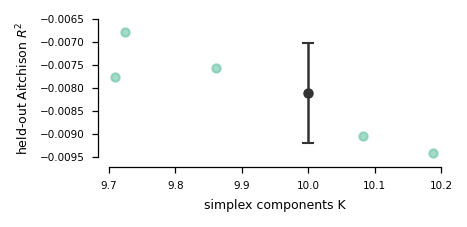

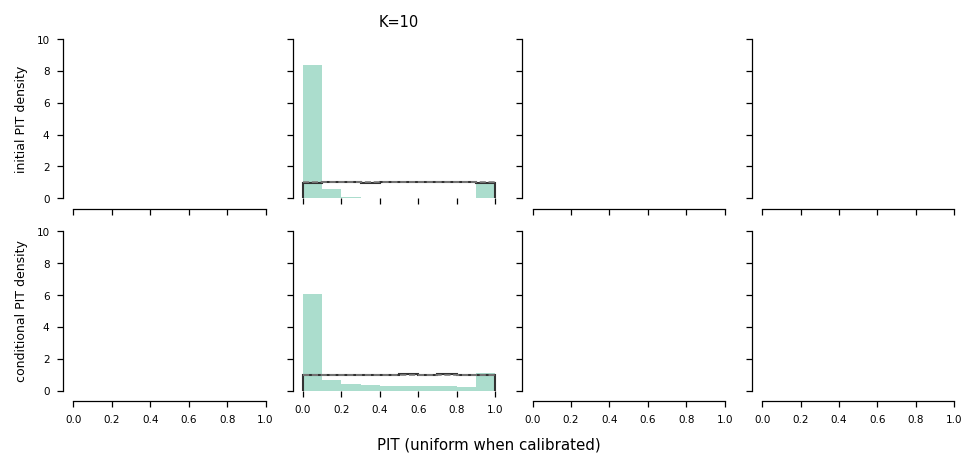

In [20]:
fig, ax = plt.subplots(figsize=(P_width, 2 * P_height))
rng = np.random.default_rng(0)
means, stds = [], []
for n in dirichlet_ns:
    values = np.array([m["r2"] for m in dirichlet_metrics[n].values()])
    means.append(values.mean() if len(values) else np.nan)
    stds.append(values.std(ddof=1) if len(values) > 1 else 0.0)
    ax.scatter(
        n + rng.uniform(-0.3, 0.3, len(values)),
        values,
        color=CAT_COLORS[0],
        alpha=0.6,
    )
ax.errorbar(dirichlet_ns, means, yerr=stds, marker="o", color="0.2", capsize=3)
ax.set(xlabel="simplex components K", ylabel="held-out Aitchison $R^2$")
plt.savefig(
    plot_folder + "randstep_dirichlet_aitchison_r2.pdf", bbox_inches="tight"
)
plt.show()

bins = np.linspace(0.0, 1.0, 11)
fig, axs = plt.subplots(
    2,
    len(dirichlet_ns),
    figsize=(1.6 * len(dirichlet_ns), 3),
    sharex=True,
    sharey=True,
    squeeze=False,
)
for col, n in enumerate(dirichlet_ns):
    metrics = list(dirichlet_metrics[n].values())
    if not metrics:
        continue
    for row, (source_key, model_key) in enumerate(
        (("initial_source_pit", "initial_model_pit"), ("source", "model"))
    ):
        source = (
            metrics[0][source_key]
            if row == 0
            else metrics[0][source_key]["pit"]
        )
        model = np.concatenate(
            [
                (metric[model_key] if row == 0 else metric[model_key]["pit"]).reshape(-1)
                for metric in metrics
            ]
        )
        axs[row, col].hist(
            source.reshape(-1),
            bins=bins,
            density=True,
            histtype="step",
            color="0.2",
            label="source",
        )
        axs[row, col].hist(
            model,
            bins=bins,
            density=True,
            alpha=0.55,
            color=CAT_COLORS[0],
            label="model",
        )
        axs[row, col].axhline(1.0, color="0.5", linestyle="--", linewidth=0.8)
    axs[0, col].set_title(f"K={n}")
axs[0, 0].set_ylabel("initial PIT density")
axs[1, 0].set_ylabel("conditional PIT density")
fig.supxlabel("PIT (uniform when calibrated)")
axs[0, -1].legend(frameon=False)
plt.savefig(plot_folder + "randstep_dirichlet_pit.pdf", bbox_inches="tight")
plt.show()


### Comparison of Dirichlet entropy estimators

The cells below add the kNN condition to the KDE evaluation above.

In [21]:
dirichlet_condition_labels = {
    "kde": "Dirichlet KDE",
    "knn": "kNN",
}
dirichlet_runs_by_condition = {"kde": dirichlet_runs}

for condition in ("knn",):
    condition_runs = {n: {} for n in dirichlet_ns}
    for n in dirichlet_ns:
        model_name = f"randstep_dirichlet_{condition}_{n}"
        root = Path("../trained_models") / model_name
        if root.is_dir():
            for seed, ckpt_dir in get_checkpoints_by_seed(model_name).items():
                print(f"Loading {model_name}: seed={seed}")
                condition_runs[n][seed] = load_model_from_ckpt_dir(ckpt_dir)
        if not condition_runs[n]:
            print(f"No {condition} checkpoints found for K={n}")
    dirichlet_runs_by_condition[condition] = condition_runs


Seed set to 3


Loading randstep_dirichlet_knn_5: seed=1


Seed set to 3


Loading randstep_dirichlet_knn_5: seed=2


Seed set to 3


...

Loading randstep_dirichlet_koleo_20: seed=4


Seed set to 3


Loading randstep_dirichlet_koleo_20: seed=3


Seed set to 3


Loading randstep_dirichlet_koleo_20: seed=5


In [22]:
dirichlet_metrics_by_condition = {"kde": dirichlet_metrics}
for condition in ("knn",):
    dirichlet_metrics_by_condition[condition] = {
        n: {
            seed: dirichlet_diagnostics(run)
            for seed, run in runs.items()
        }
        for n, runs in dirichlet_runs_by_condition[condition].items()
    }

for condition, metrics_by_n in dirichlet_metrics_by_condition.items():
    for n, seed_metrics in metrics_by_n.items():
        for seed, metric in seed_metrics.items():
            initial_ks = _uniform_ks_by_component(
                metric["initial_model_pit"].reshape(-1, n)
            ).max()
            print(
                f"{condition}, K={n}, seed={seed}: "
                f"Aitchison R2={metric['r2']:.3f}, "
                f"initial PIT D(max)={initial_ks:.3f}, "
                f"conditional PIT D(max)={metric['model']['ks_max']:.3f}, "
                f"variance ratio={metric['model']['variance_ratio']:.3f}"
            )


kde, K=10, seed=1: Aitchison R2=-0.009, initial PIT D(max)=1.000, conditional PIT D(max)=0.886, variance ratio=1.133
kde, K=10, seed=3: Aitchison R2=-0.008, initial PIT D(max)=1.000, conditional PIT D(max)=1.000, variance ratio=1.350
kde, K=10, seed=2: Aitchison R2=-0.007, initial PIT D(max)=1.000, conditional PIT D(max)=1.000, variance ratio=1.917
kde, K=10, seed=4: Aitchison R2=-0.008, initial PIT D(max)=1.000, conditional PIT D(max)=1.000, variance ratio=1.235
kde, K=10, seed=5: Aitchison R2=-0.009, initial PIT D(max)=1.000, conditional PIT D(max)=0.908, variance ratio=1.172
knn, K=5, seed=1: Aitchison R2=0.007, initial PIT D(max)=1.000, conditional PIT D(max)=0.872, variance ratio=1.065
knn, K=5, seed=2: Aitchison R2=0.004, initial PIT D(max)=1.000, conditional PIT D(max)=0.883, variance ratio=1.091
knn, K=5, seed=3: Aitchison R2=0.002, initial PIT D(max)=1.000, conditional PIT D(max)=0.878, variance ratio=1.076
knn, K=5, seed=4: Aitchison R2=0.002, initial PIT D(max)=1.000, condit

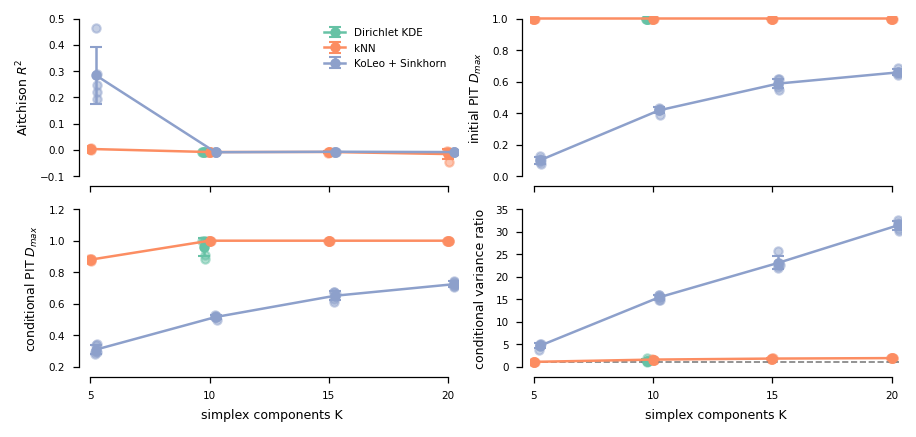

In [23]:
condition_colors = {
    condition: CAT_COLORS[index]
    for index, condition in enumerate(dirichlet_condition_labels)
}
summary_metrics = {
    "Aitchison $R^2$": lambda metric, n: metric["r2"],
    "initial PIT $D_{max}$": lambda metric, n: _uniform_ks_by_component(
        metric["initial_model_pit"].reshape(-1, n)
    ).max(),
    "conditional PIT $D_{max}$": lambda metric, n: metric["model"]["ks_max"],
    "conditional variance ratio": lambda metric, n: metric["model"]["variance_ratio"],
}
fig, axs = plt.subplots(2, 2, figsize=(2 * P_width, 4 * P_height), sharex=True)
rng = np.random.default_rng(0)
offsets = np.linspace(-0.25, 0.25, len(dirichlet_condition_labels))

for ax, (ylabel, extractor) in zip(axs.flat, summary_metrics.items()):
    for offset, (condition, label) in zip(
        offsets, dirichlet_condition_labels.items()
    ):
        means, stds = [], []
        for n in dirichlet_ns:
            metrics = dirichlet_metrics_by_condition[condition][n].values()
            values = np.array([extractor(metric, n) for metric in metrics])
            means.append(values.mean() if len(values) else np.nan)
            stds.append(values.std(ddof=1) if len(values) > 1 else 0.0)
            ax.scatter(
                n + offset + rng.uniform(-0.05, 0.05, len(values)),
                values,
                color=condition_colors[condition],
                alpha=0.5,
            )
        ax.errorbar(
            np.asarray(dirichlet_ns) + offset,
            means,
            yerr=stds,
            marker="o",
            color=condition_colors[condition],
            capsize=3,
            label=label,
        )
    ax.set_ylabel(ylabel)
    ax.set_xticks(dirichlet_ns)
axs[1, 0].set_xlabel("simplex components K")
axs[1, 1].set_xlabel("simplex components K")
axs[1, 1].axhline(1.0, color="0.5", linestyle="--", linewidth=0.8)
axs[0, 0].legend(frameon=False)
plt.savefig(
    plot_folder + "randstep_dirichlet_loss_comparison.pdf",
    bbox_inches="tight",
)
plt.show()


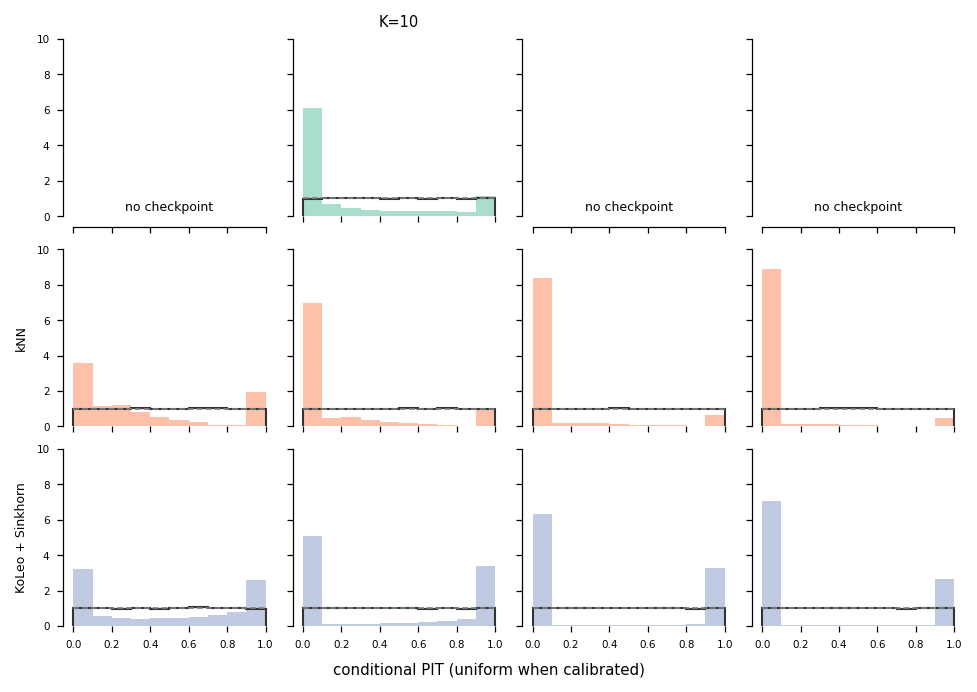

In [24]:
bins = np.linspace(0.0, 1.0, 11)
fig, axs = plt.subplots(
    len(dirichlet_condition_labels),
    len(dirichlet_ns),
    figsize=(1.6 * len(dirichlet_ns), 1.5 * len(dirichlet_condition_labels)),
    sharex=True,
    sharey=True,
    squeeze=False,
)
for row, (condition, label) in enumerate(dirichlet_condition_labels.items()):
    for col, n in enumerate(dirichlet_ns):
        ax = axs[row, col]
        metrics = list(dirichlet_metrics_by_condition[condition][n].values())
        if not metrics:
            ax.text(0.5, 0.5, "no checkpoint", ha="center", va="center")
            continue
        source_pit = metrics[0]["source"]["pit"].reshape(-1)
        model_pit = np.concatenate(
            [metric["model"]["pit"].reshape(-1) for metric in metrics]
        )
        ax.hist(
            source_pit,
            bins=bins,
            density=True,
            histtype="step",
            color="0.2",
            label="source",
        )
        ax.hist(
            model_pit,
            bins=bins,
            density=True,
            alpha=0.55,
            color=condition_colors[condition],
            label=label,
        )
        ax.axhline(1.0, color="0.5", linestyle="--", linewidth=0.8)
        if row == 0:
            ax.set_title(f"K={n}")
        if col == 0:
            ax.set_ylabel(label)
fig.supxlabel("conditional PIT (uniform when calibrated)")
axs[0, 0].legend(frameon=False)
plt.savefig(
    plot_folder + "randstep_dirichlet_loss_pit.pdf", bbox_inches="tight"
)
plt.show()
